# EDA — User Logs: Comportamiento de Escucha vs Churn
Agrega `user_logs.csv` (~392M filas) + `user_logs_v2.csv` por chunks, construye features  
por usuario y compara comportamiento de escucha entre churners y renewals.  

> **Nota:** la primera ejecución tarda ~10 min por el volumen del archivo (28 GB).

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.eda.user_logs_04 import (
    load_log_features,
    build_log_features,
    analyze_logs,
    plot_listening_vs_churn,
    plot_listening_trend,
    plot_churn_by_recency,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Agregación por chunks (~10 min)

In [2]:
raw_agg = load_log_features()

Cargando caché de user_logs (user_logs_agg.parquet)...


In [3]:
print(f'Shape agregado: {raw_agg.shape}')
raw_agg.head()

Shape agregado: (5234111, 9)


,msno,n_days,total_secs_sum,num_100_sum,num_unq_sum,total_songs_sum,recent_n_days,recent_total_secs_sum,max_date
0,+++4vcS9aMH7KWdfh5git6nA5fC5jjisd5H/NcM++WM=,1,9.741100e+01,0,2,2,0,0.000,20150427
1,+++EI4HgyhgcJHIPXk/VRP7bt17+2joG39T6oEfJ+tc=,1,5.686800e+01,0,1,2,0,0.000,20160420
2,+++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY=,7,4.999677e+04,171,179,264,0,0.000,20160915
3,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,622,1.466484e+07,59354,53604,60842,18,220564.147,20170227
4,+++TipL0Kt3JvgNE9ahuJ8o+drJAnQINtxD4c5GePXI=,1,3.661527e+03,14,22,23,0,0.000,20151230


## 2. Derivar features por usuario

In [4]:
df_features = build_log_features(raw_agg)
print(f'Features shape: {df_features.shape}')
df_features[[
    'msno', 'n_days', 'avg_daily_secs', 'avg_daily_completed',
    'completion_ratio', 'days_since_last', 'listening_trend'
]].describe()

Features shape: (5234111, 16)


,n_days,avg_daily_secs,avg_daily_completed,completion_ratio,days_since_last,listening_trend
count,5.234111e+06,5.234111e+06,5.234111e+06,5.234111e+06,5.234111e+06,5.234111e+06
mean,7.491369e+01,3.866732e+03,1.368686e+01,4.852131e-01,3.055546e+02,-2.527686e+03
std,1.613528e+02,4.903356e+03,2.046929e+01,3.247298e-01,2.464645e+02,4.406113e+03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-8.640000e+04
25%,1.000000e+00,6.216585e+02,1.000000e+00,1.836735e-01,6.000000e+01,-3.529895e+03
50%,3.000000e+00,2.355994e+03,7.166667e+00,5.286941e-01,2.890000e+02,-1.239982e+03
75%,3.200000e+01,5.282500e+03,1.878200e+01,7.636242e-01,4.980000e+02,-2.521840e+02
max,7.900000e+02,8.640000e+04,9.046167e+03,1.000000e+00,7.890000e+02,8.292205e+04


## 3. Cruzar con etiquetas de churn

In [5]:
DATA_RAW = ROOT / 'data' / 'raw'
labels = pd.read_csv(DATA_RAW / 'train.csv')[['msno', 'is_churn']]
print(f'Labels: {len(labels):,} usuarios | churn rate: {labels["is_churn"].mean():.2%}')

Labels: 992,931 usuarios | churn rate: 6.39%


In [6]:
results = analyze_logs(df_features, labels)

Usuarios en análisis: 869,926 | churn rate: 6.57%

════════════════════════════════════════════════════════════
USER LOGS — Churn vs Renewal
                     Renewal (0)    Churn (1)  diff_%
n_days                285.263899   239.570709   -16.0
avg_daily_secs       6529.158743  6755.369462     3.5
avg_daily_completed    24.548806    25.234357     2.8
avg_daily_unq          24.995054    26.259614     5.1
completion_ratio        0.679897     0.675186    -0.7
days_since_last        24.657291    40.343090    63.6
listening_trend      -772.403208 -2063.827845  -167.2

── Churn rate por recencia del último log ──
                churn_rate       n
recency_bucket                    
<1w               0.046373  255776
1w-1m             0.236800   91081
1-2m              0.195130   28089
2-3m              0.088518   12167
3-6m              0.080935   19114
6m+               0.087074   41413


In [7]:
# Tabla resumen con lift
summary = results['summary'].copy()
summary['lift'] = (summary['Churn (1)'] / summary['Renewal (0)']).round(2)
summary

,Renewal (0),Churn (1),diff_%,lift
n_days,285.263899,239.570709,-16.0,0.84
avg_daily_secs,6529.158743,6755.369462,3.5,1.03
avg_daily_completed,24.548806,25.234357,2.8,1.03
avg_daily_unq,24.995054,26.259614,5.1,1.05
completion_ratio,0.679897,0.675186,-0.7,0.99
days_since_last,24.657291,40.343090,63.6,1.64
listening_trend,-772.403208,-2063.827845,-167.2,2.67


## 4. Distribuciones por grupo: Churn vs Renewal

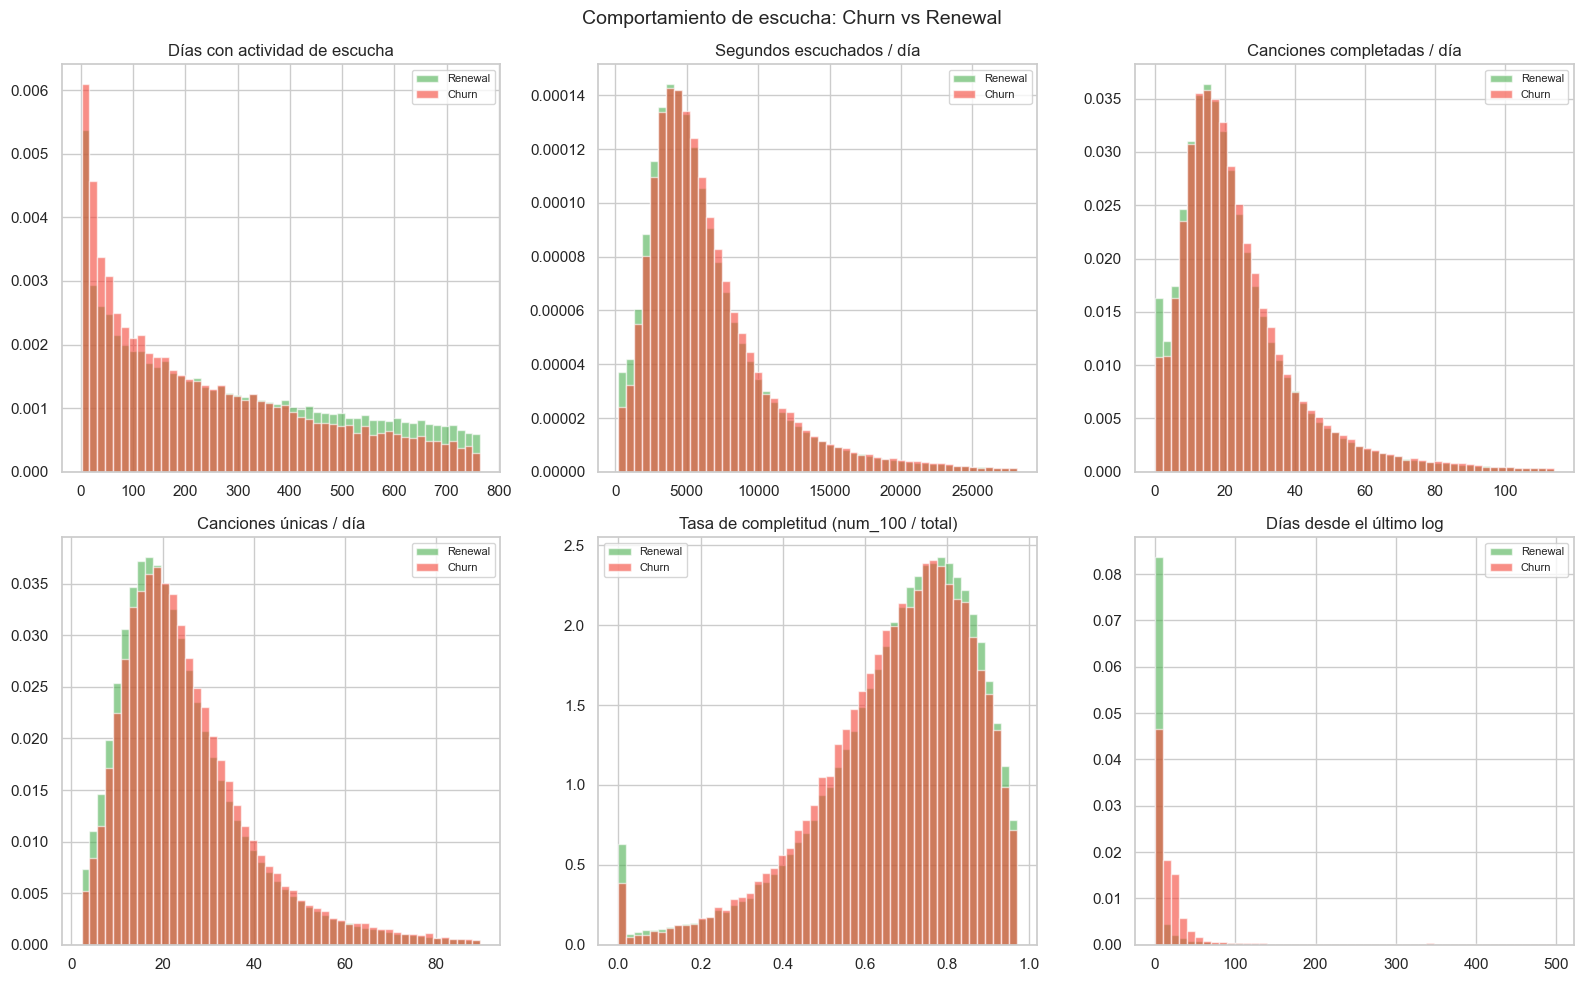

In [8]:
plot_listening_vs_churn(results['merged'])

## 5. Tendencia de escucha: últimos 30 días vs histórico

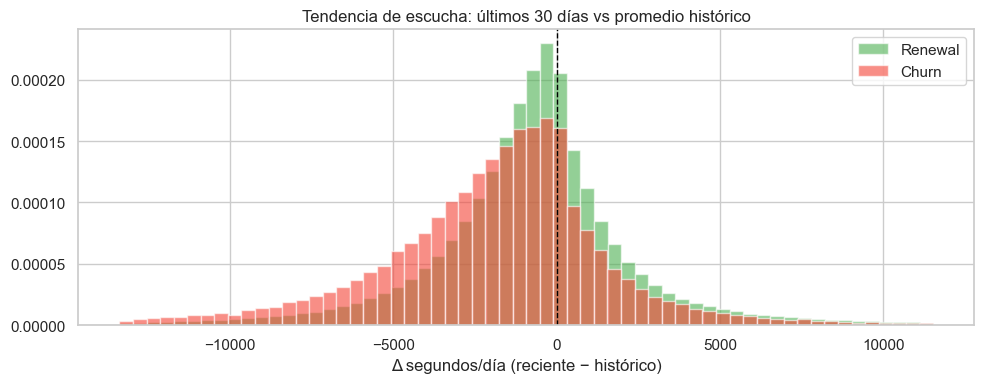

In [9]:
plot_listening_trend(results['merged'])

## 6. Churn rate por recencia del último log

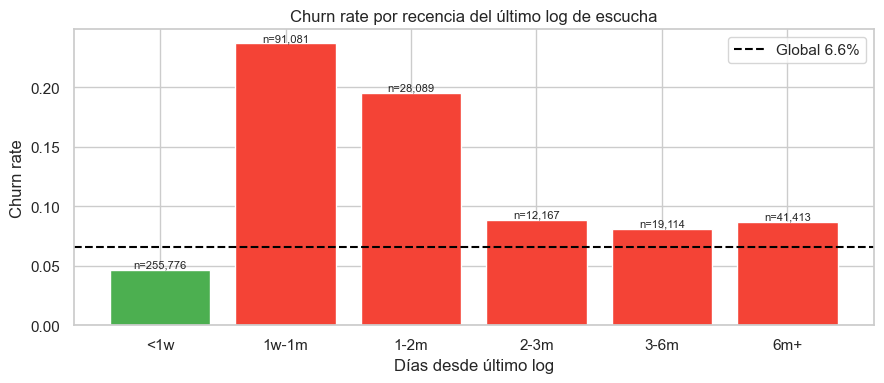

In [10]:
plot_churn_by_recency(results)

In [11]:
results['recency_churn']

,churn_rate,n
recency_bucket,,
<1w,0.046373,255776
1w-1m,0.236800,91081
1-2m,0.195130,28089
2-3m,0.088518,12167
3-6m,0.080935,19114
6m+,0.087074,41413


## 7. Usuarios sin logs vs churn

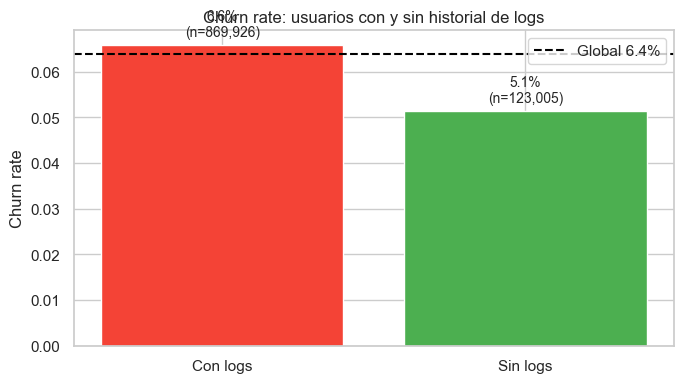

In [12]:
# ¿Qué pasa con usuarios de train que NO tienen logs?
merged = results['merged']
all_train = labels.copy()
has_logs = all_train['msno'].isin(df_features['msno'])

no_logs_churn = all_train[~has_logs]['is_churn'].mean()
with_logs_churn = merged['is_churn'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
groups = ['Con logs', 'Sin logs']
rates = [with_logs_churn, no_logs_churn]
colors = ['#4CAF50' if r < all_train['is_churn'].mean() else '#F44336' for r in rates]
ax.bar(groups, rates, color=colors, edgecolor='white')
ax.axhline(all_train['is_churn'].mean(), color='black', linestyle='--',
           label=f'Global {all_train["is_churn"].mean():.1%}')
for i, (g, r) in enumerate(zip(groups, rates)):
    n = len(merged) if i == 0 else (~has_logs).sum()
    ax.text(i, r + 0.002, f'{r:.1%}\n(n={n:,})', ha='center', fontsize=10)
ax.set_title('Churn rate: usuarios con y sin historial de logs')
ax.set_ylabel('Churn rate')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Resumen de hallazgos

| Feature | Renewal | Churn | Señal |
|---|---|---|---|
| `n_days` | más días activos | menos días activos | ↑ más días → menos churn |
| `avg_daily_secs` | mayor escucha/día | menor escucha/día | ↑ escucha → menos churn |
| `completion_ratio` | similar | similar | señal débil |
| `days_since_last` | próximo a 0 (activos) | alto (inactivos) | **señal fuerte** |
| `listening_trend` | estable/positivo | negativo (caída reciente) | **señal fuerte** |

**`days_since_last` es la señal más importante**: usuarios que no escucharon nada en los últimos meses tienen churn rate muy superior al promedio.